# Problem 3.1

Bayesian linear regression places a prior on the weights and computes the posterior.

### Model Specification

The generative process for Bayesian Linear Regression is defined as:

$$
\begin{aligned}
y_i &= w^\top \phi(x_i) + \epsilon_i \\
\epsilon_i &\sim \mathcal{N}(0, \sigma^2) \\
w &\sim \mathcal{N}(0, \tau^2 \mathbf{I})
\end{aligned}
$$

Where:
* $\phi(x_i)$ is the **feature map** (e.g., $[1, x, x^2, \dots, x^d]$ for polynomial features).
* $\sigma^2$ is the **noise variance**.
* $\tau^2$ is the **prior variance** (regularization strength).

---

### Matrix Form

For all observations $i = 1, \dots, n$, we can write this compactly as:

$$
\begin{aligned}
\mathbf{y} &= \Phi \mathbf{w} + \mathbf{\epsilon} \\
\mathbf{\epsilon} &\sim \mathcal{N}(\mathbf{0}, \sigma^2 \mathbf{I}) \\
\mathbf{w} &\sim \mathcal{N}(\mathbf{0}, \tau^2 \mathbf{I})
\end{aligned}
$$

Where $\Phi$ is the $n \times d$ **design matrix** such that $\Phi_{ij} = \phi_j(x_i)$.

### Bayesian Posterior Definition
The weight vector $w$ is distributed according to the posterior:

$$p(w | D) = \mathcal{N}(w | \mu_N, S_N)$$

Where:
* **Covariance:** $S_N = (\tau^{-2}I + \sigma^{-2}\Phi^T\Phi)^{-1}$ 
($\tau^{-2}I$ - prior initial guess, $\sigma^{-2}\Phi^T\Phi$ - data prediciton, based on the MLE method)
* **Mean:** $\mu_N = \sigma^{-2}S_N\Phi^T y$

In [59]:
import pymc as pm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# load data 
df = pd.read_csv('advertising.csv')

# choosing only TV from the dataset
X_raw = df['TV'].values.reshape(-1, 1)
y = df['Sales'].values

# standardize features for MCMC stability
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).flatten()
# allows to fit curve 
X_poly = np.stack([X_scaled, X_scaled**2], axis=1)

In [62]:
# OLS - MLE for comparison (no prior weights)
mle_model = LinearRegression().fit(X_poly, y)
x_grid = np.linspace(X_scaled.min(), X_scaled.max(), 100).reshape(-1, 1)
x_grid_poly = np.concatenate([x_grid, x_grid**2], axis=1)
y_mle_pred = mle_model.predict(x_grid_poly)

# bayesian linear regression PYMC
# where we want to be with the data
mu_proposed = 0
# how uncertain we are
proposed_sigma=10
with pm.Model() as model:
    # Priors initialization
    beta0 = pm.Normal("Intercept", mu=y.mean(), sigma=proposed_sigma)
    beta = pm.Normal("Weights", mu=0, sigma=proposed_sigma, shape=2)
    sigma = pm.Exponential("Noise", lam=1.0)
    
    # Linear combination
    mu = beta0 + beta[0] * X_poly[:, 0] + beta[1] * X_poly[:, 1]
    
    # Likelihood 
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)
    # sample - creating the posterior distribution by wandering 
    trace = pm.sample(2000, tune=1000, chains=5, target_accept=0.95)

# posterior part
with model:
    # generate expected value predictions
    mu_grid = beta0 + beta[0] * x_grid_poly[:, 0] + beta[1] * x_grid_poly[:, 1]
    post_pred = pm.sample_posterior_predictive(trace, var_names=["Intercept", "Weights"])
    
    # extract posterior samples to manually plot credible intervals
    post_beta0 = trace.posterior["Intercept"].values.flatten()
    post_beta = trace.posterior["Weights"].values.reshape(-1, 2)
    
    # calculate expected y for every posterior sample across the grid
    mu_samples = post_beta0[:, None] + (post_beta[:, 0, None] * x_grid_poly[:, 0]) + (post_beta[:, 1, None] * x_grid_poly[:, 1])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (5 chains in 4 jobs)
NUTS: [Intercept, Weights, Noise]


Output()

Sampling 5 chains for 1_000 tune and 2_000 draw iterations (5_000 + 10_000 draws total) took 5 seconds.
Sampling: [Intercept, Weights]


Output()

array([<Axes: title={'center': 'Weights\n0'}>,
       <Axes: title={'center': 'Weights\n1'}>], dtype=object)

<Figure size 1200x800 with 0 Axes>

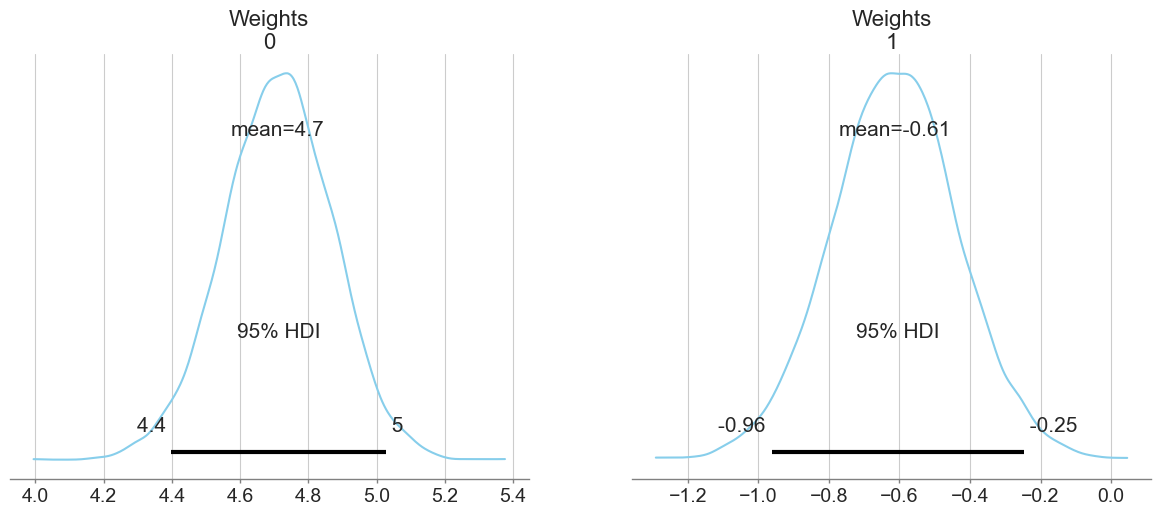

In [63]:
# Posteriors distribution
plt.figure(figsize=(12,8))
az.plot_posterior(
    trace, 
    var_names=["Weights"],
    hdi_prob=0.95,
    point_estimate="mean",
    color="skyblue",
    round_to=2
)

# Left -> β0
# Right -> β1

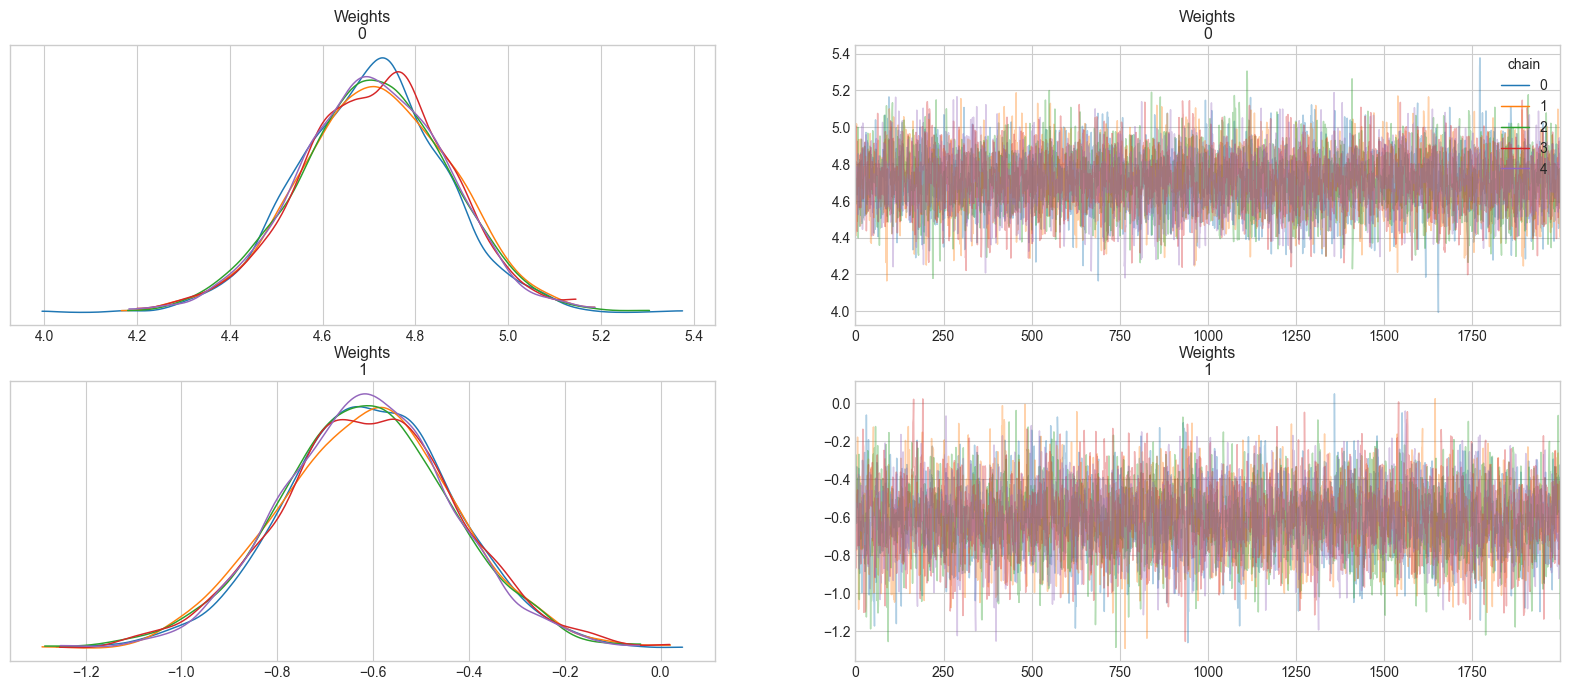

In [67]:
# Plot trace walking
plt = az.plot_trace(trace, var_names=["Weights"],figsize=(20,8),legend=True,compact=False,
    combined=False,
    lines=[("Weights", {}, [mle_model.coef_[0], mle_model.coef_[1]])] 
)

/var/folders/hn/gx3zxz4516s7kxrlbtw0ygmh0000gp/T/ipykernel_5664/803187521.py:9: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(mu_samples, hdi_prob=0.95)


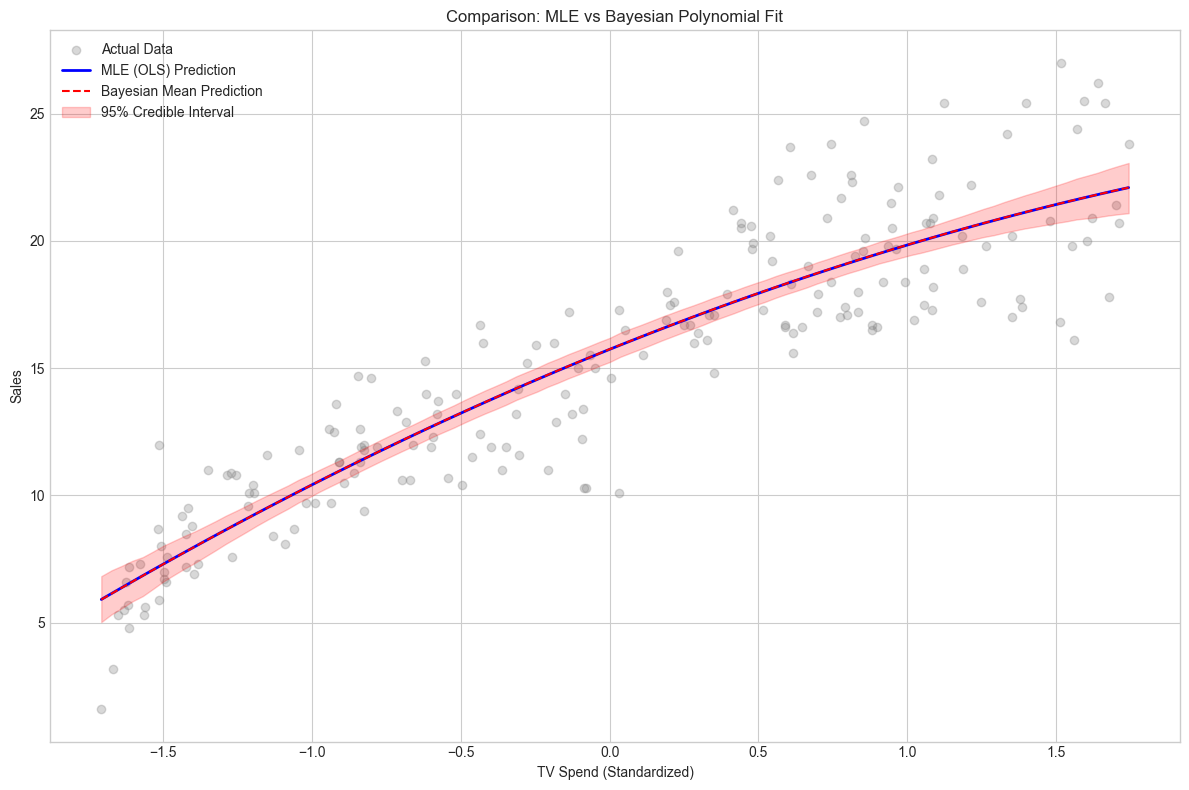

MLE Coefficients: Intercept=15.7409, Beta=[ 4.7076512  -0.61035158]

Bayesian Logistic Regression Summary:
              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
Intercept   15.746  0.240  15.282   16.191      0.003    0.002    5131.0    5588.0    1.0
Weights[0]   4.710  0.159   4.404    5.003      0.002    0.002    8011.0    6847.0    1.0
Weights[1]  -0.613  0.182  -0.936   -0.247      0.003    0.002    5183.0    5932.0    1.0


In [143]:
# Bayesian vs MLE
plt.figure(figsize=(12,8))
plt.scatter(X_scaled, y, alpha=0.3, label="Actual Data", color='gray')
plt.plot(x_grid, y_mle_pred, color='blue', lw=2, label="MLE (OLS) Prediction")

# Plot Bayesian mean and Credible Interval
mu_mean = mu_samples.mean(axis=0)
#credible interval
hdi = az.hdi(mu_samples, hdi_prob=0.95)
plt.plot(x_grid, mu_mean, color='red', linestyle='--', label="Bayesian Mean Prediction")
plt.fill_between(x_grid.flatten(), hdi[:, 0], hdi[:, 1], color='red', alpha=0.2, label="95% Credible Interval")

plt.title("Comparison: MLE vs Bayesian Polynomial Fit")
plt.xlabel("TV Spend (Standardized)")
plt.ylabel("Sales")
plt.legend()

plt.tight_layout()
plt.show()

# summary comparison
print(f"MLE Coefficients: Intercept={mle_model.intercept_:.4f}, Beta={mle_model.coef_}")
print("\nBayesian Logistic Regression Summary:")
print(az.summary(trace, var_names=["Intercept", "Weights"]).to_string())

# Problem 3.2

### From Weights to Functions: Gaussian Processes (GP)

In Bayesian Linear Regression, we placed a prior on the weight vectors $w$. A **Gaussian Process (GP)** shifts this perspective by placing a prior **directly on the space of functions**:

$$f \sim \mathcal{GP}(m, k)$$

#### 1. Finite Dimensional Definition
For any finite collection of inputs $x_1, \dots, x_n$, the function values $\mathbf{f} = (f(x_1), \dots, f(x_n))^\top$ are jointly Gaussian:

$$\mathbf{f} \sim \mathcal{N}(\mathbf{m}, \mathbf{K})$$

#### 2. Components of the GP
A GP is fully defined by two functions:

* **Mean Function ($m$):** $m(x) = \mathbb{E}[f(x)]$. This is often set to $0$ for simplicity.
* **Covariance Function ($k$):** $k(x, x') = \text{Cov}[f(x), f(x')]$. Also called the **Kernel**, it determines the "shape" of the functions.

#### 3. The Kernel Matrix ($\mathbf{K}$)
The kernel matrix $\mathbf{K}$ is constructed such that $K_{ij} = k(x_i, x_j)$. This matrix encodes our structural assumptions:
* **Smoothness:** How "wiggly" the function is.
* **Periodicity:** If the function repeats (like seasonal data).
* **Stationarity:** If the relationship between points only depends on their distance.

---
> **Key Insight:** While Bayesian Linear Regression is limited by your choice of features $\phi(x)$, a GP can be viewed as a linear model with an **infinite** number of features.

# Test

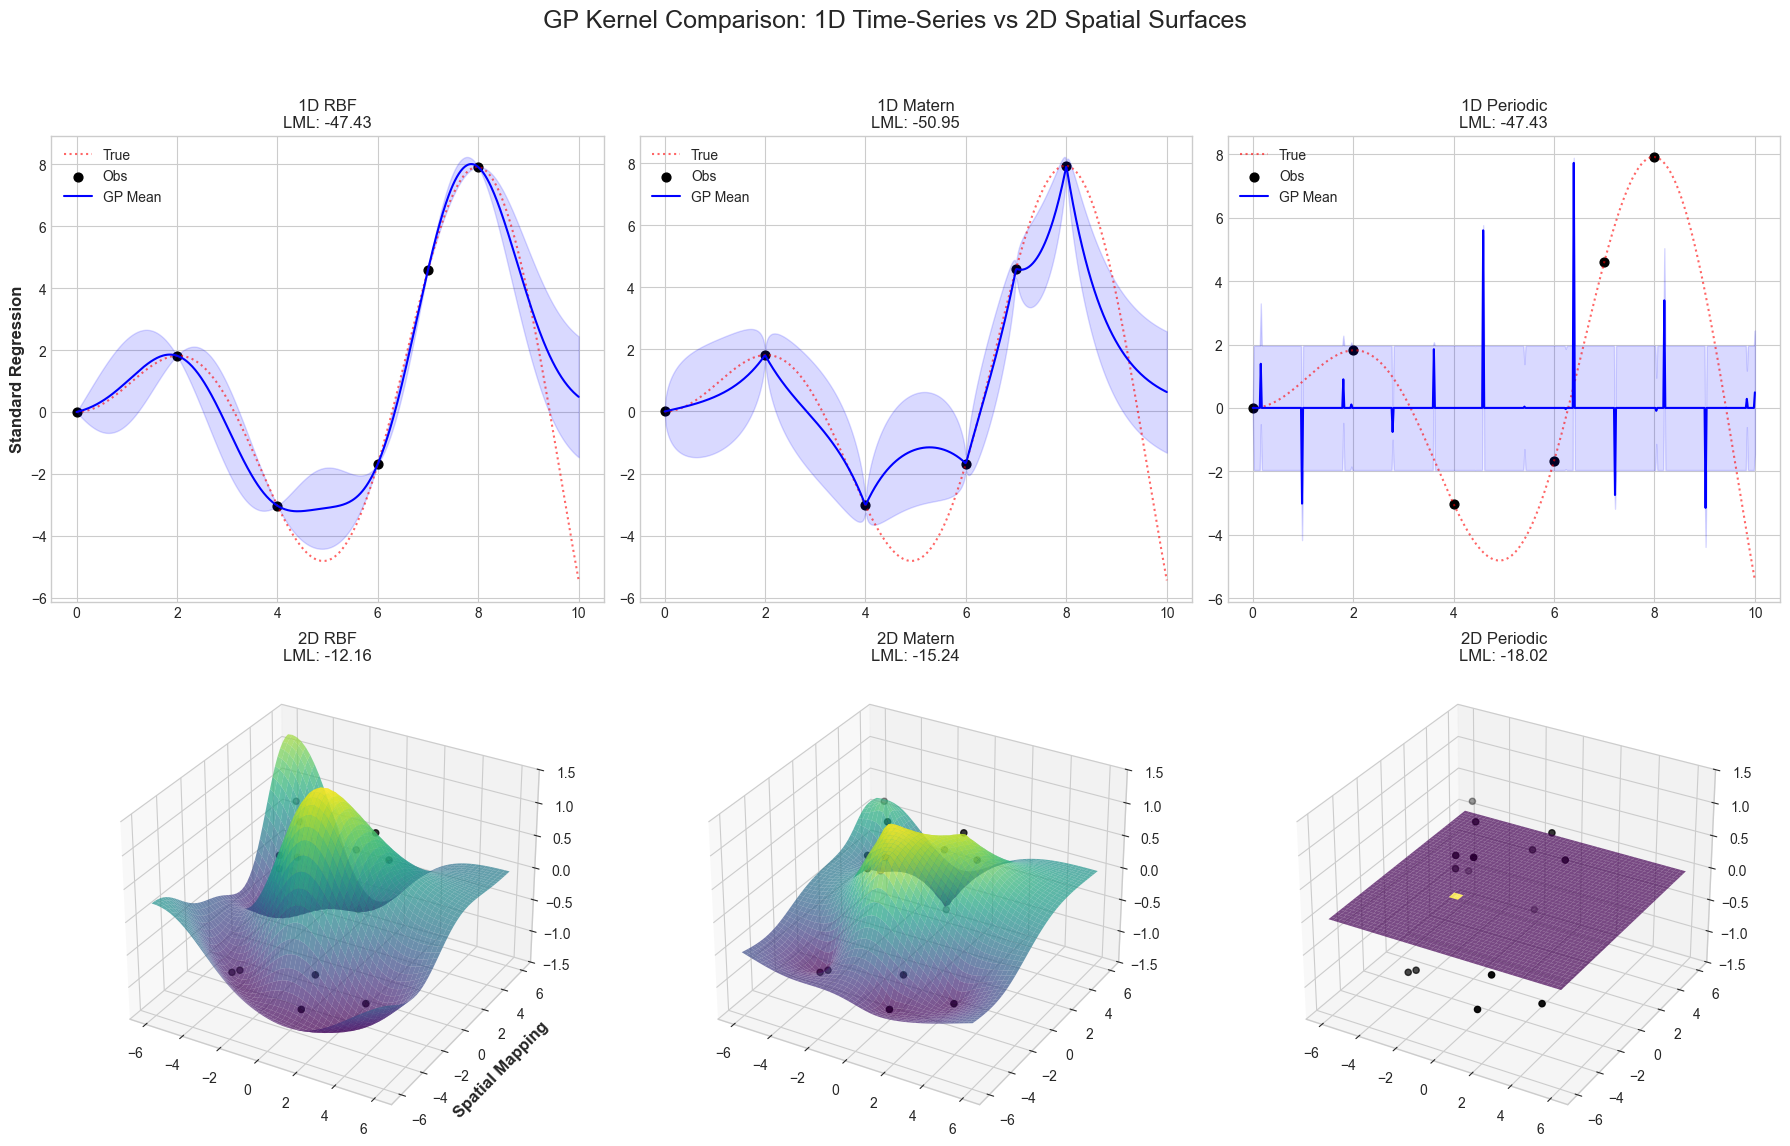

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ExpSineSquared, WhiteKernel, ConstantKernel as C, DotProduct

# --- DATA GENERATION ---
def target_func_1d(x):
    return x * np.sin(x)

def target_func_2d(x):
    return np.sin(np.sqrt(x[:, 0]**2 + x[:, 1]**2))

# 1D Setup
np.random.seed(42)
X_train_1d = np.array([0, 2, 4, 6,7, 8]).reshape(-1, 1)
y_train_1d = target_func_1d(X_train_1d).flatten()
x_plot_1d = np.linspace(0, 10, 500).reshape(-1, 1)

# 2D Setup
np.random.seed(42)
X_train_2d = np.random.uniform(-5, 5, (15, 2)) # Increased slightly for better surface visibility
y_train_2d = target_func_2d(X_train_2d)

grid_lim, res = 6, 50
x1 = np.linspace(-grid_lim, grid_lim, res)
x2 = np.linspace(-grid_lim, grid_lim, res)
X1, X2 = np.meshgrid(x1, x2)
X_plot_2d = np.vstack([X1.ravel(), X2.ravel()]).T

# --- KERNEL DEFINITIONS ---
kernel_names = ["RBF", "Matern", "Periodic"]
kernels_list = [
    RBF(length_scale=1),
    Matern(length_scale=1, nu=0.5),
    ExpSineSquared(length_scale=1, periodicity=3.0)
]

# --- PLOTTING ---
fig = plt.figure(figsize=(18, 12))

for i, (name, kernel) in enumerate(zip(kernel_names, kernels_list)):
    
    # ROW 1: 1D GAUSSIAN PROCESS
    ax1 = fig.add_subplot(2, 3, i + 1)
    gp1 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10).fit(X_train_1d, y_train_1d)
    y_pred_1d, sigma_1d = gp1.predict(x_plot_1d, return_std=True)
    
    ax1.plot(x_plot_1d, target_func_1d(x_plot_1d), 'r:', alpha=0.6, label="True")
    ax1.scatter(X_train_1d, y_train_1d, c='black', s=40, label="Obs")
    ax1.plot(x_plot_1d, y_pred_1d, 'b-', label="GP Mean")
    ax1.fill_between(x_plot_1d.flatten(), y_pred_1d - 1.96*sigma_1d, y_pred_1d + 1.96*sigma_1d, alpha=0.15, color='blue')
    ax1.set_title(f"1D {name}\nLML: {gp1.log_marginal_likelihood_value_:.2f}")
    if i == 0: ax1.set_ylabel("Standard Regression", fontsize=12, fontweight='bold')
    ax1.legend(loc='upper left')

    # ROW 2: 2D GAUSSIAN PROCESS
    ax2 = fig.add_subplot(2, 3, i + 4, projection='3d')
    gp2 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10).fit(X_train_2d, y_train_2d)
    y_pred_2d = gp2.predict(X_plot_2d).reshape(res, res)
    
    surf = ax2.plot_surface(X1, X2, y_pred_2d, cmap='viridis', alpha=0.7, edgecolor='none')
    ax2.scatter(X_train_2d[:, 0], X_train_2d[:, 1], y_train_2d, c='black', s=20)
    ax2.set_title(f"2D {name}\nLML: {gp2.log_marginal_likelihood_value_:.2f}")
    if i == 0: ax2.set_ylabel("Spatial Mapping", fontsize=12, fontweight='bold')
    ax2.set_zlim(-1.5, 1.5)

plt.suptitle("GP Kernel Comparison: 1D Time-Series vs 2D Spatial Surfaces", fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Fun fact about the data

In [93]:
# load data mauna loa CO2
df = pd.read_csv('archive.csv')
# using the year
X_1d = df['Decimal Date'].values.reshape(-1, 1)
y_1d = df['Carbon Dioxide (ppm)'].values.flatten()
# Data Cleaning
mask = pd.isna(y_1d)
X_1d, y_1d = X_1d[mask], y_1d[mask]
print(X_1d,y_1d)

[[1958.0411]
 [1958.126 ]
 [1958.4548]
 [1958.789 ]
 [1964.1257]
 [1964.2049]
 [1964.2896]
 [2017.2027]
 [2017.2877]
 [2017.3699]
 [2017.4548]
 [2017.537 ]
 [2017.6219]
 [2017.7068]
 [2017.789 ]
 [2017.874 ]
 [2017.9562]] [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


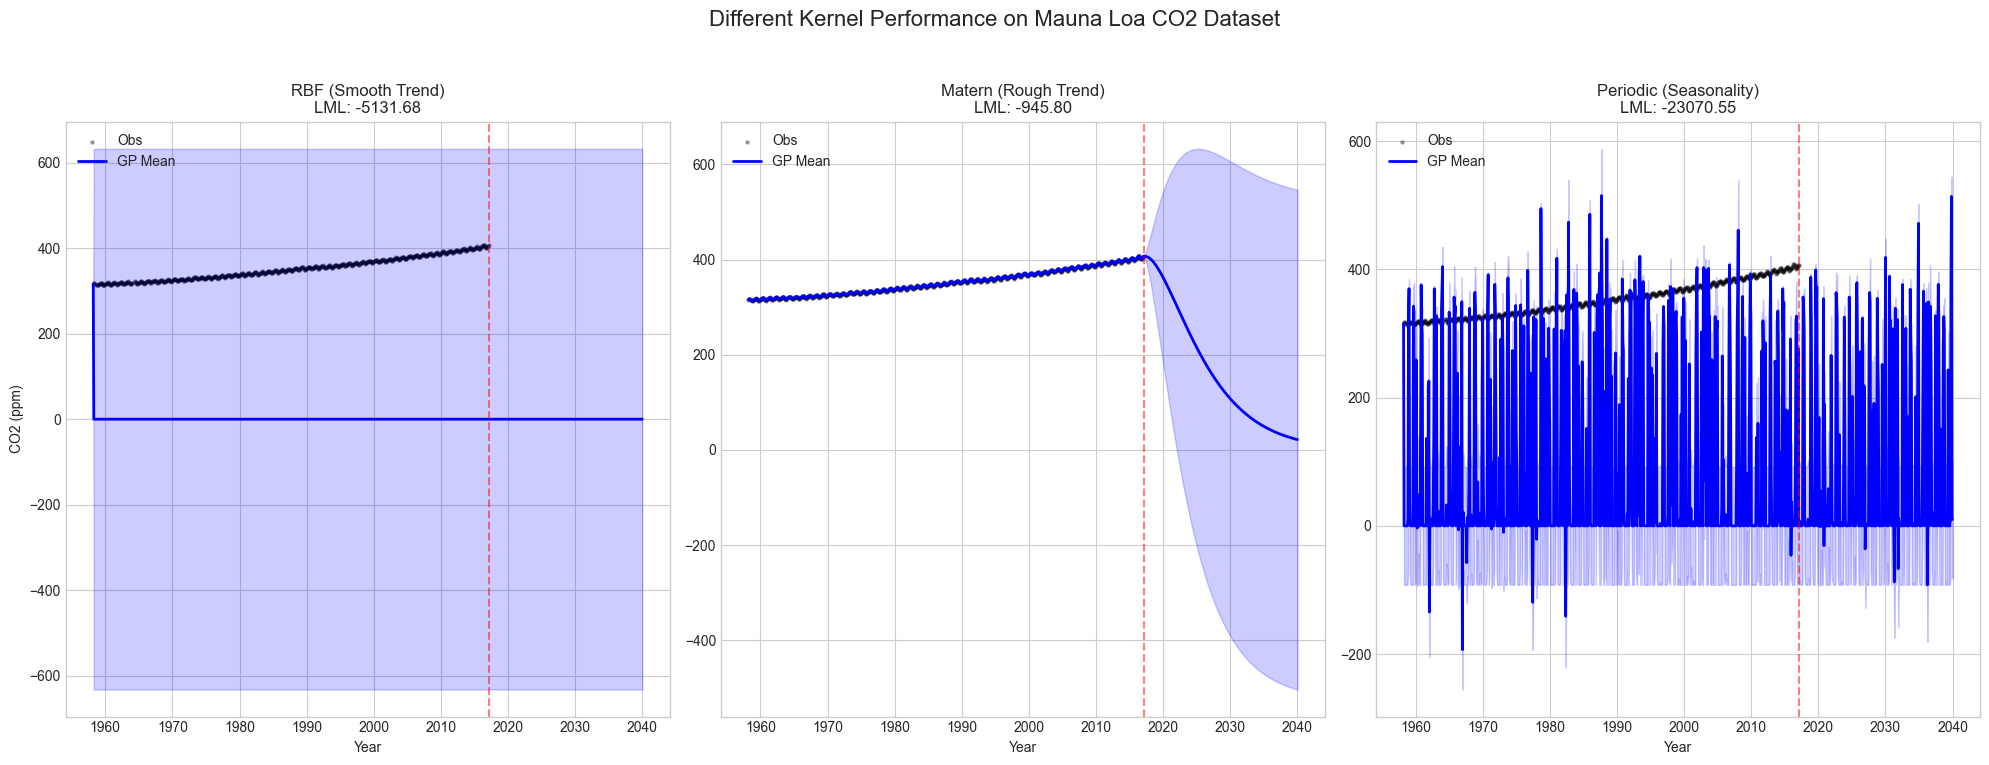

In [155]:
df = pd.read_csv('archive.csv')
X_1d = df['Decimal Date'].values.reshape(-1, 1)
y_1d = df['Carbon Dioxide (ppm)'].values.flatten()

mask = y_1d > 0
X_1d_clean, y_1d_clean = X_1d[mask], y_1d[mask]
# scaling to only 400 points
step = max(1, len(X_1d_clean) // 400)
X_1d_train, y_1d_train = X_1d_clean[::step], y_1d_clean[::step]
# setup test grid for forecasting up to 2040
X_1d_test = np.linspace(X_1d_clean.min(), 2040, 1000).reshape(-1, 1)

# different kernels
# we use C(400**2) as a 'prior' for the vertical scale since CO2 starts around 320-400ppm
kernels = [
    ("RBF (Smooth Trend)", C(400**2) * RBF(length_scale=1)),
    ("Matern (Rough Trend)", C(400**2) * Matern(length_scale=1.0, nu=1.5)),
    ("Periodic (Seasonality)", C(400**2) * ExpSineSquared(length_scale=1.0, periodicity=1.0))
]

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# loop through kernels 
for ax, (name, kernel) in zip(axes, kernels):
    # fit the model
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5,random_state=42)
    gp.fit(X_1d_train, y_1d_train)
    
    y_mean, y_std = gp.predict(X_1d_test, return_std=True)
    
    ax.scatter(X_1d_train, y_1d_train, c='black', s=5, alpha=0.3, label='Obs')
    ax.plot(X_1d_test, y_mean, color='blue', lw=2, label='GP Mean')
    ax.fill_between(X_1d_test.flatten(), y_mean - 2*y_std, y_mean + 2*y_std, color='blue', alpha=0.2)
    
    # line for the end of training data
    ax.axvline(X_1d_train.max(), color='red', linestyle='--', alpha=0.5)
    
    ax.set_title(f"{name}\nLML: {gp.log_marginal_likelihood_value_:.2f}")
    ax.set_xlabel("Year")
    if ax == axes[0]: 
        ax.set_ylabel("CO2 (ppm)")
    ax.legend(loc='upper left')

plt.suptitle("Different Kernel Performance on Mauna Loa CO2 Dataset", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# RBF + Maternal + ExpSineSquared + WhiteNoise

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


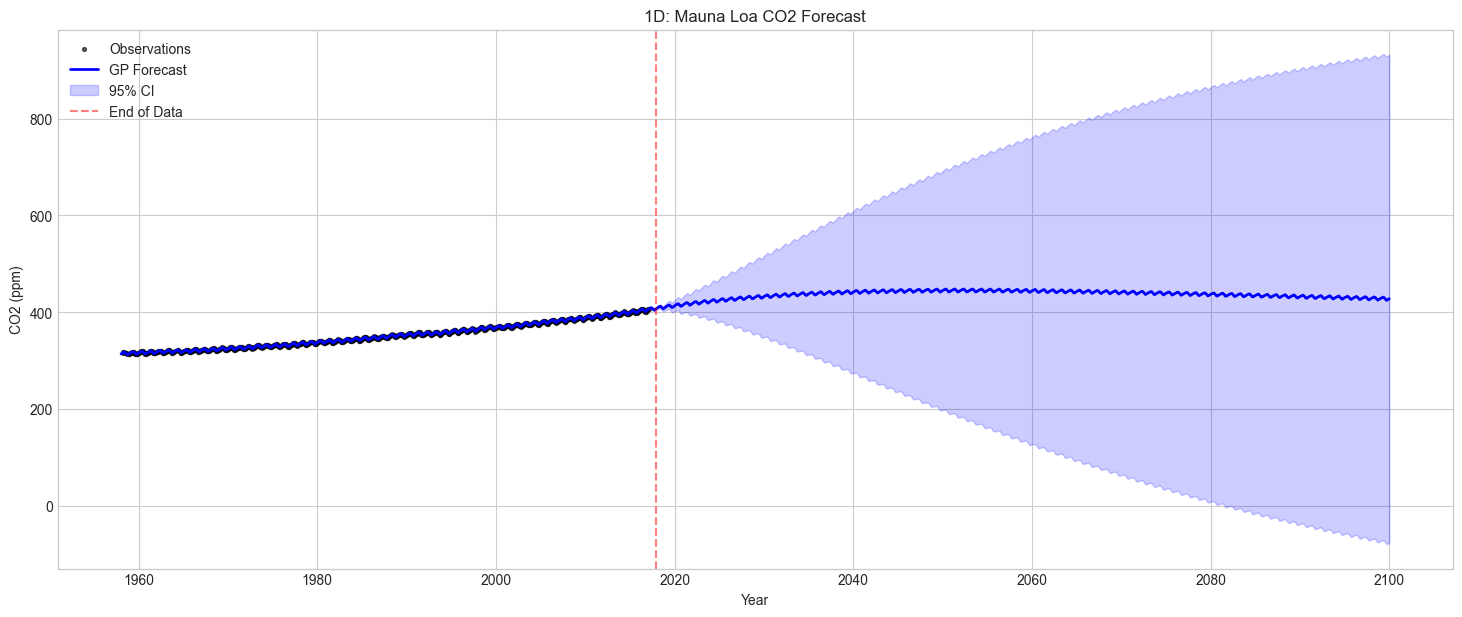

Optimized 1D Kernel: 50**2 * RBF(length_scale=50) + 1.98**2 * ExpSineSquared(length_scale=1.35, periodicity=1) + 233**2 * Matern(length_scale=68.1, nu=1.5) + 9.93**2 * DotProduct(sigma_0=1) + WhiteKernel(noise_level=0.0692)


In [142]:
# load data mauna loa CO2
df = pd.read_csv('archive.csv')
# using the year
X_1d = df['Decimal Date'].values.reshape(-1, 1)
y_1d = df['Carbon Dioxide (ppm)'].values.flatten()

mask = y_1d > 0
X_1d_train, y_1d_train = X_1d[mask], y_1d[mask]

#scaling the data to actual fluctuations

kernel_1d = (
    # 1. Long-term smooth trend (Decadal)
    C(50.0**2) * RBF(length_scale=50.0) + 
    
    # 2. Seasonal wiggles (Annual)
    C(2.0**2) * ExpSineSquared(length_scale=1.0, periodicity=1.0) + 
    
    # 3. Medium-term irregularities
    C(400**2) * Matern(length_scale=50.0, nu=1.5) +
    
    # 4. LINEAR TREND (Prevents the crash to zero)
    C(10.0**2) * DotProduct(sigma_0=1.0) +
    
    # 5. Noise floor
    WhiteKernel(noise_level=0.1)
)
# 1D Model (real data)
gp_1d = GaussianProcessRegressor(kernel=kernel_1d, n_restarts_optimizer=5).fit(X_1d_train, y_1d_train)

# 1D Prediction up to 2040
X_1d_test = np.linspace(X_1d.min(), 2100, 1000).reshape(-1, 1)
# return std -> for confidence interval 
y_1d_mean, y_1d_std = gp_1d.predict(X_1d_test, return_std=True)

# visualization
fig = plt.figure(figsize=(18, 7))

# CO2 Forecast
plt.scatter(X_1d_train, y_1d_train, c='black', s=8, alpha=0.6, label='Observations')
plt.plot(X_1d_test, y_1d_mean, color='blue', lw=2, label='GP Forecast')
plt.fill_between(X_1d_test.flatten(), y_1d_mean - 2*y_1d_std, y_1d_mean + 2*y_1d_std, 
                 color='blue', alpha=0.2, label='95% CI')
plt.axvline(X_1d.max(), color='red', linestyle='--', alpha=0.5, label='End of Data')
plt.title("1D: Mauna Loa CO2 Forecast")
plt.xlabel("Year")
plt.ylabel("CO2 (ppm)")
plt.legend()
plt.show()

print(f"Optimized 1D Kernel: {gp_1d.kernel_}")

# Problem 3.3

## Data

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

# download 3 years worth of data
data = yf.download('^GSPC', start='2020-01-01', end='2023-01-01')
prices = data['Close'].dropna()

prices.head()

[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC
Date,
2020-01-02,3257.850098
2020-01-03,3234.850098
2020-01-06,3246.280029
2020-01-07,3237.179932
2020-01-08,3253.050049


## ARIMA model

ADF test
p-value: 0.5235


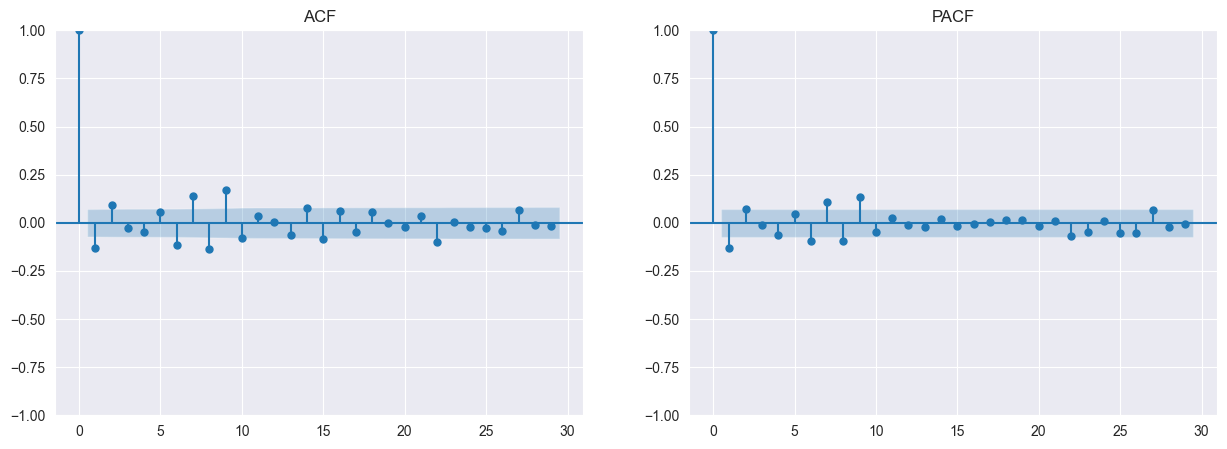

C:\Users\zawer\documents\applied_math\sem1\machine_learning\assingments\ml_assingments_venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\zawer\documents\applied_math\sem1\machine_learning\assingments\ml_assingments_venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\zawer\documents\applied_math\sem1\machine_learning\assingments\ml_assingments_venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\zawer\documents\applied_math\se

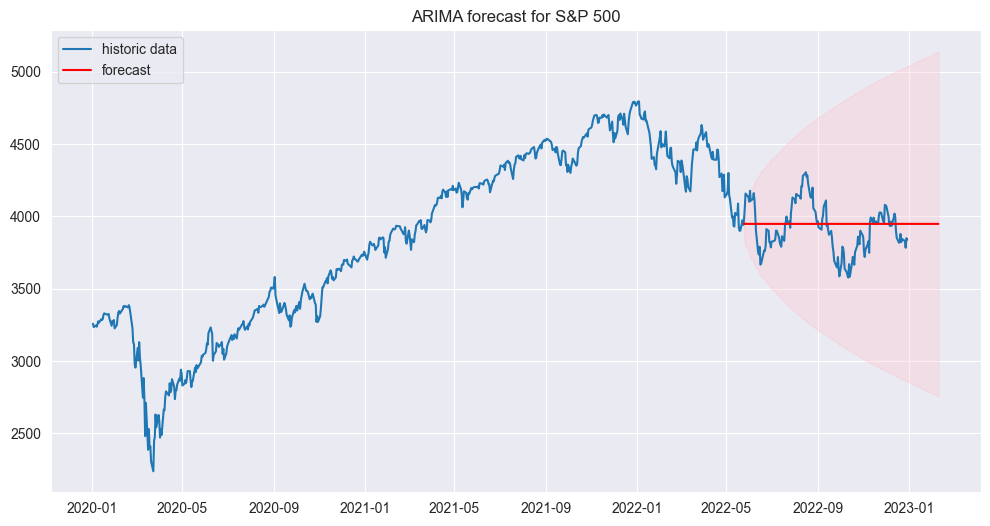

                               SARIMAX Results                                
Dep. Variable:                  ^GSPC   No. Observations:                  604
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3232.788
Date:                Sun, 26 Apr 2026   AIC                           6471.575
Time:                        18:10:54   BIC                           6484.781
Sample:                             0   HQIC                          6476.715
                                - 604                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4842      0.091     -5.297      0.000      -0.663      -0.305
ma.L1          0.2994      0.100      2.981      0.003       0.103       0.496
sigma2      2655.5719     89.518     29.665      0.0

In [6]:
# ADF test
print("ADF test")
adf_result = adfuller(prices)
print(f"p-value: {adf_result[1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(prices.diff().dropna(), ax=ax1, title="ACF")
plot_pacf(prices.diff().dropna(), ax=ax2, title="PACF")
plt.show()

# split into test and train
split = int(len(prices) * 0.8)
train_prices, test_prices = prices.iloc[:split], prices.iloc[split:]

# fit ARIMA
model_arima = ARIMA(train_prices, order=(1, 1, 1))
res_arima = model_arima.fit()

# forecast
forecast_steps = len(test_prices) + 30
forecast_obj = res_arima.get_forecast(steps=forecast_steps)
forecast_mean = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

future_dates = pd.bdate_range(start=test_prices.index[-1] + pd.Timedelta(days=1), periods=30)
forecast_dates = test_prices.index.append(future_dates)

forecast_mean.index = forecast_dates
conf_int.index = forecast_dates

plt.figure(figsize=(12, 6))
plt.plot(prices.index, prices, label='historic data')
plt.plot(forecast_mean.index, forecast_mean, color='red', label='forecast')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('ARIMA forecast for S&P 500')
plt.legend()
plt.show()

print(res_arima.summary())

# Problem 3.4

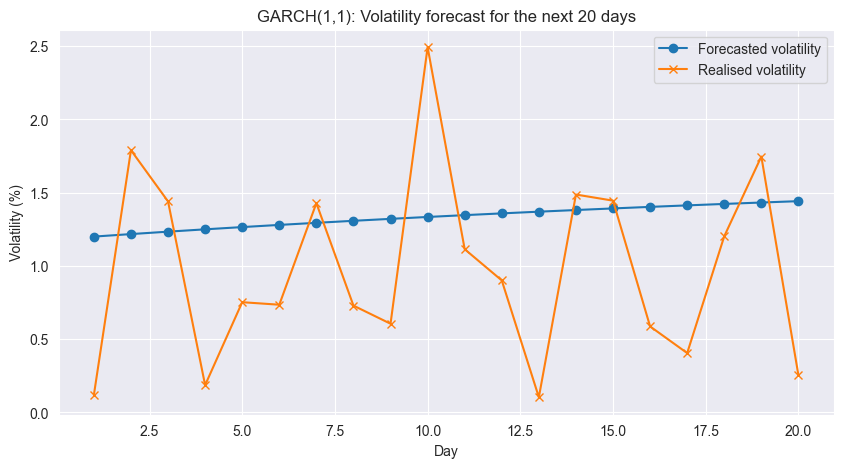

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  ^GSPC   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1225.92
Distribution:                  Normal   AIC:                           2459.84
Method:            Maximum Likelihood   BIC:                           2478.34
                                        No. Observations:                  755
Date:                Sun, Apr 26 2026   Df Residuals:                      754
Time:                        18:10:56   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0797  3.814e-02      2.090  3.665e-02 [4.947e-0

In [7]:
# calculating log-returns (*100 for better stability)
returns = prices.pct_change().dropna() * 100

# fitting GARCH(1,1)
model_garch = arch_model(returns, vol='Garch', p=1, q=1)
res_garch = model_garch.fit(disp='off')

# forecast for the next 20 days
forecast_garch = res_garch.forecast(horizon=20)
# calculating volatility
pred_vol = np.sqrt(forecast_garch.variance.values[-1, :])

# validation using realized volatility
realized_vol = np.abs(returns[-20:])

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), pred_vol, marker='o', label='Forecasted volatility')
plt.plot(range(1, 21), realized_vol.values, marker='x', label='Realised volatility')
plt.title('GARCH(1,1): Volatility forecast for the next 20 days')
plt.xlabel('Day')
plt.ylabel('Volatility (%)')
plt.legend()
plt.show()

print(res_garch.summary())